In [1]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import healpy as hp
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # You can change this font if you prefer
    "axes.labelsize": 14,  # Adjust as needed
    "axes.titlesize": 16,  # Adjust as needed
    "xtick.labelsize": 14,  # Adjust as needed
    "ytick.labelsize": 14,  # Adjust as needed
    "legend.fontsize": 12,  # Adjust as needed
    "figure.figsize": (15, 8),  # Adjust as needed
    "figure.dpi": 600  # Adjust as needed
})
from shear_psf_leakage.rho_tau_stat import RhoStat, TauStat, PSFErrorFit

import treecorr

from getdist import plots, MCSamples

%matplotlib inline

In [2]:
base_dir = '/n17data/mkilbing/astro/data/CFIS/v1.0/ShapePipe/'
path_gal = base_dir + 'unions_shapepipe_extended_2022_v1.4.0.fits'
path_psf = base_dir + 'unions_shapepipe_psf_conv_2022_v1.4.0.fits'

cat_gal = fits.getdata(path_gal)
cat_psf = fits.getdata(path_psf)

In [3]:
ra = cat_gal['RA']
dec = cat_gal['DEC']

theta = (90 - dec) * np.pi / 180
phi = ra * np.pi / 180

nside = 2**12
print(f"nside: {nside}")
pix = hp.ang2pix(nside, theta, phi)

n_map = np.zeros(hp.nside2npix(nside))

unique_pix, idx, idx_pix = np.unique(pix, return_index=True, return_inverse=True)

n_map[unique_pix] += np.bincount(idx_pix, weights=cat_gal['w'])

mask = (n_map != 0)

In [ ]:
area = np.sum(mask)*hp.nside2pixarea(nside, degrees=True)
print(f'Area: {area} deg^2')

n_eff_gal = 1/(area*60*60)*(np.sum(cat_gal['w']))**2/np.sum(cat_gal['w']**2)
print(f'Effective number of galaxies: {n_eff_gal}')

n_eff_psf = 1/(area*60*60)*(len(cat_psf))**2/np.sum(len(cat_psf))
print(f'Effective number of PSFs: {n_eff_psf}')

sigma_e = np.sqrt(
    0.5*(np.sum((cat_gal['e1']*cat_gal['w'])**2) + np.sum((cat_gal['e2']*cat_gal['w'])**2)) / np.sum(cat_gal['w']**2)
)
print(f'Intrinsic shape noise: {sigma_e}')

Area: 3135.3602943406763 deg^2
Effective number of galaxies: 7.853461190377332
Effective number of PSFs: 0.5807322129800436
Intrinsic shape noise: 0.31118289741939353


In [ ]:
mask_path = '/n17data/mkilbing/astro/data/CFIS/v1.0/Lensfit/masks/CFIS3500_THELI_mask_hp_8192.fits.gz'
mask_theli = hp.read_map(mask_path)

nside = hp.npix2nside(len(mask_theli))
area = np.sum(mask_theli == 0) * hp.nside2pixarea(nside, degrees=True)
print(f'Area: {area} deg^2')

Area: 2137.7977618140676 deg^2


## Plot comparison between catalogs

Class created. Don't forget to load your rho and tau statistics and define your prior and your likelihood.
Plotting version: SP_v1.4.1
Plotting version: SP_v1.4.1_noleakage


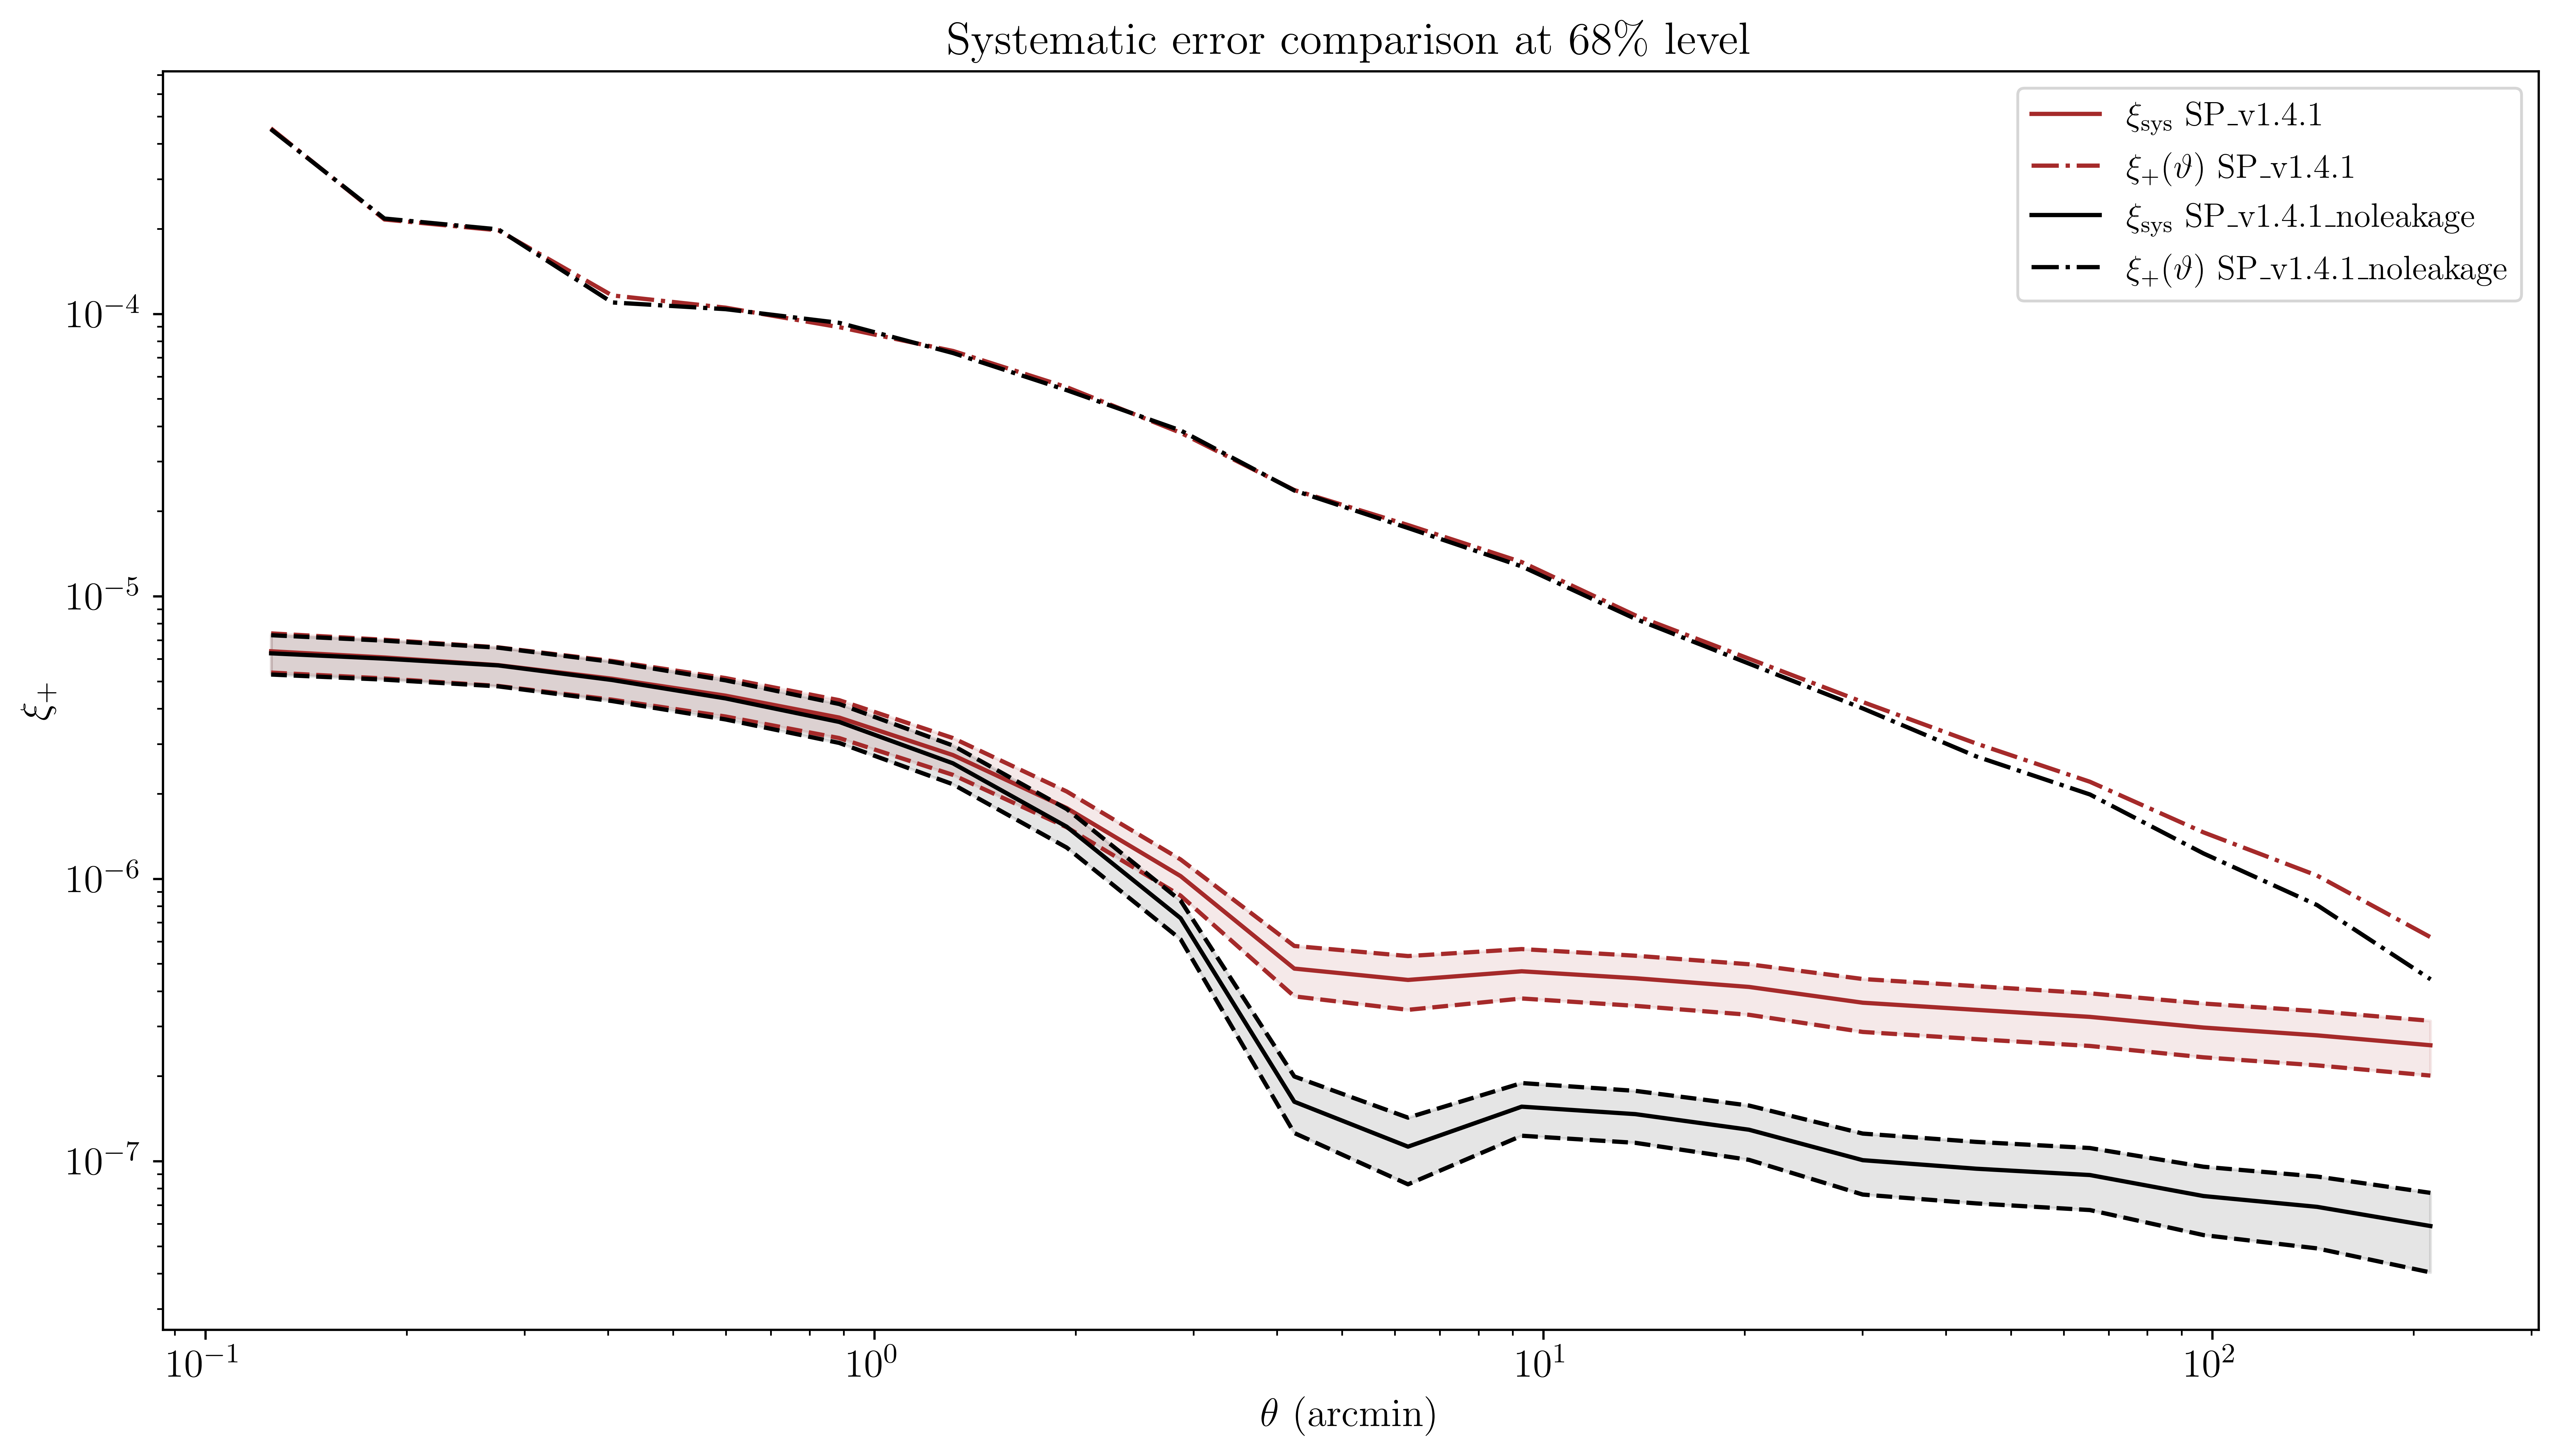

In [2]:
#versions = ['SP_v1.3_LFmask_8k', 'SP_v1.3_LFmask_8k_no_alpha', 'SP_v1.4-P1+3', 'SP_v1.4-P1+3_no_alpha', 'DES']
#versions = ['SP_v1.3_LFmask_8k', 'SP_v1.3_LFmask_8k_no_alpha', 'SP_v1.4.1', 'SP_v1.4.1_noleakage', 'DES']
versions = ['SP_v1.4.1', 'SP_v1.4.1_noleakage']
#colors = ['blue', 'blueviolet', 'brown', 'black', 'orange']
#colors = ['blue', 'blueviolet', 'black', 'brown', 'orange']
colors = ['brown', 'black']
root_dir = '/home/guerrini/sp_validation/notebooks/cosmo_val/output/'

#Inference of the xi_sys parameters
sep_units = 'arcmin'
coord_units = 'degrees'
theta_min = 0.1
theta_max = 250
nbins = 20


TreeCorrConfig_xi = {
    'ra_units': coord_units,
    'dec_units': coord_units,
    'min_sep': theta_min,
    'max_sep': theta_max,
    'sep_units': sep_units,
    'nbins': nbins,
    'var_method':'jackknife',
}

rho_stats_handler = RhoStat(
    output='.',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
)

tau_stats_handler = TauStat(
    catalogs=rho_stats_handler.catalogs,
    output='.',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
    )

psf_fitter = PSFErrorFit(rho_stats_handler, tau_stats_handler, root_dir+'/rho_tau_stats/')

#plot of the xi_sys
plt.figure()

for ver, color in zip(versions, colors):
    print("Plotting version:", ver)
    sample = np.load(root_dir+'rho_tau_stats/samples_'+ver+'.npy')
    psf_fitter.load_rho_stat('rho_stats_'+ver+'.fits')
    quant = 0.84
    quantiles = [1-quant, quant]
    nbins = psf_fitter.rho_stat_handler._treecorr_config['nbins']
    xi_psf_sys_samples = np.array([]).reshape(0, nbins)
    for i in range(len(sample)):
        xi_psf_sys = psf_fitter.compute_xi_psf_sys(sample[i])
        xi_psf_sys_samples = np.vstack((xi_psf_sys_samples, xi_psf_sys))
    
    xi_psf_sys_mean = np.mean(xi_psf_sys_samples, axis=0)
    xi_psf_sys_quant = np.quantile(xi_psf_sys_samples, quantiles, axis=0)
    theta = psf_fitter.rho_stat_handler.rho_stats['theta']
    plt.plot(theta, xi_psf_sys_mean, c=color, label=r'$\xi_{\rm sys}$ '+ver)
    plt.plot(theta, xi_psf_sys_quant[0], c=color, ls='--')
    plt.plot(theta, xi_psf_sys_quant[1], c=color, ls='--')
    plt.fill_between(theta, xi_psf_sys_quant[0], xi_psf_sys_quant[1], color=color, alpha=0.1)

    if os.path.exists(root_dir+'/xi_plus_'+ver+'.fits'):
        xi_plus = fits.getdata(root_dir+'/xi_plus_'+ver+'.fits')
        plt.plot(xi_plus['ANG'], xi_plus['VALUE'], c=color, ls='-.', label=r"$\xi_+(\vartheta)$ "+ver)
    else:
        raise ValueError("File not found")

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{+}$')
plt.legend()
plt.title("Systematic error comparison at 68\% level")
plt.savefig('Plots/xi_sys_lq_comparison.png', dpi=600)
plt.show()

Plotting version: SP_v1.4.1


Plotting version: SP_v1.4.1_noleakage


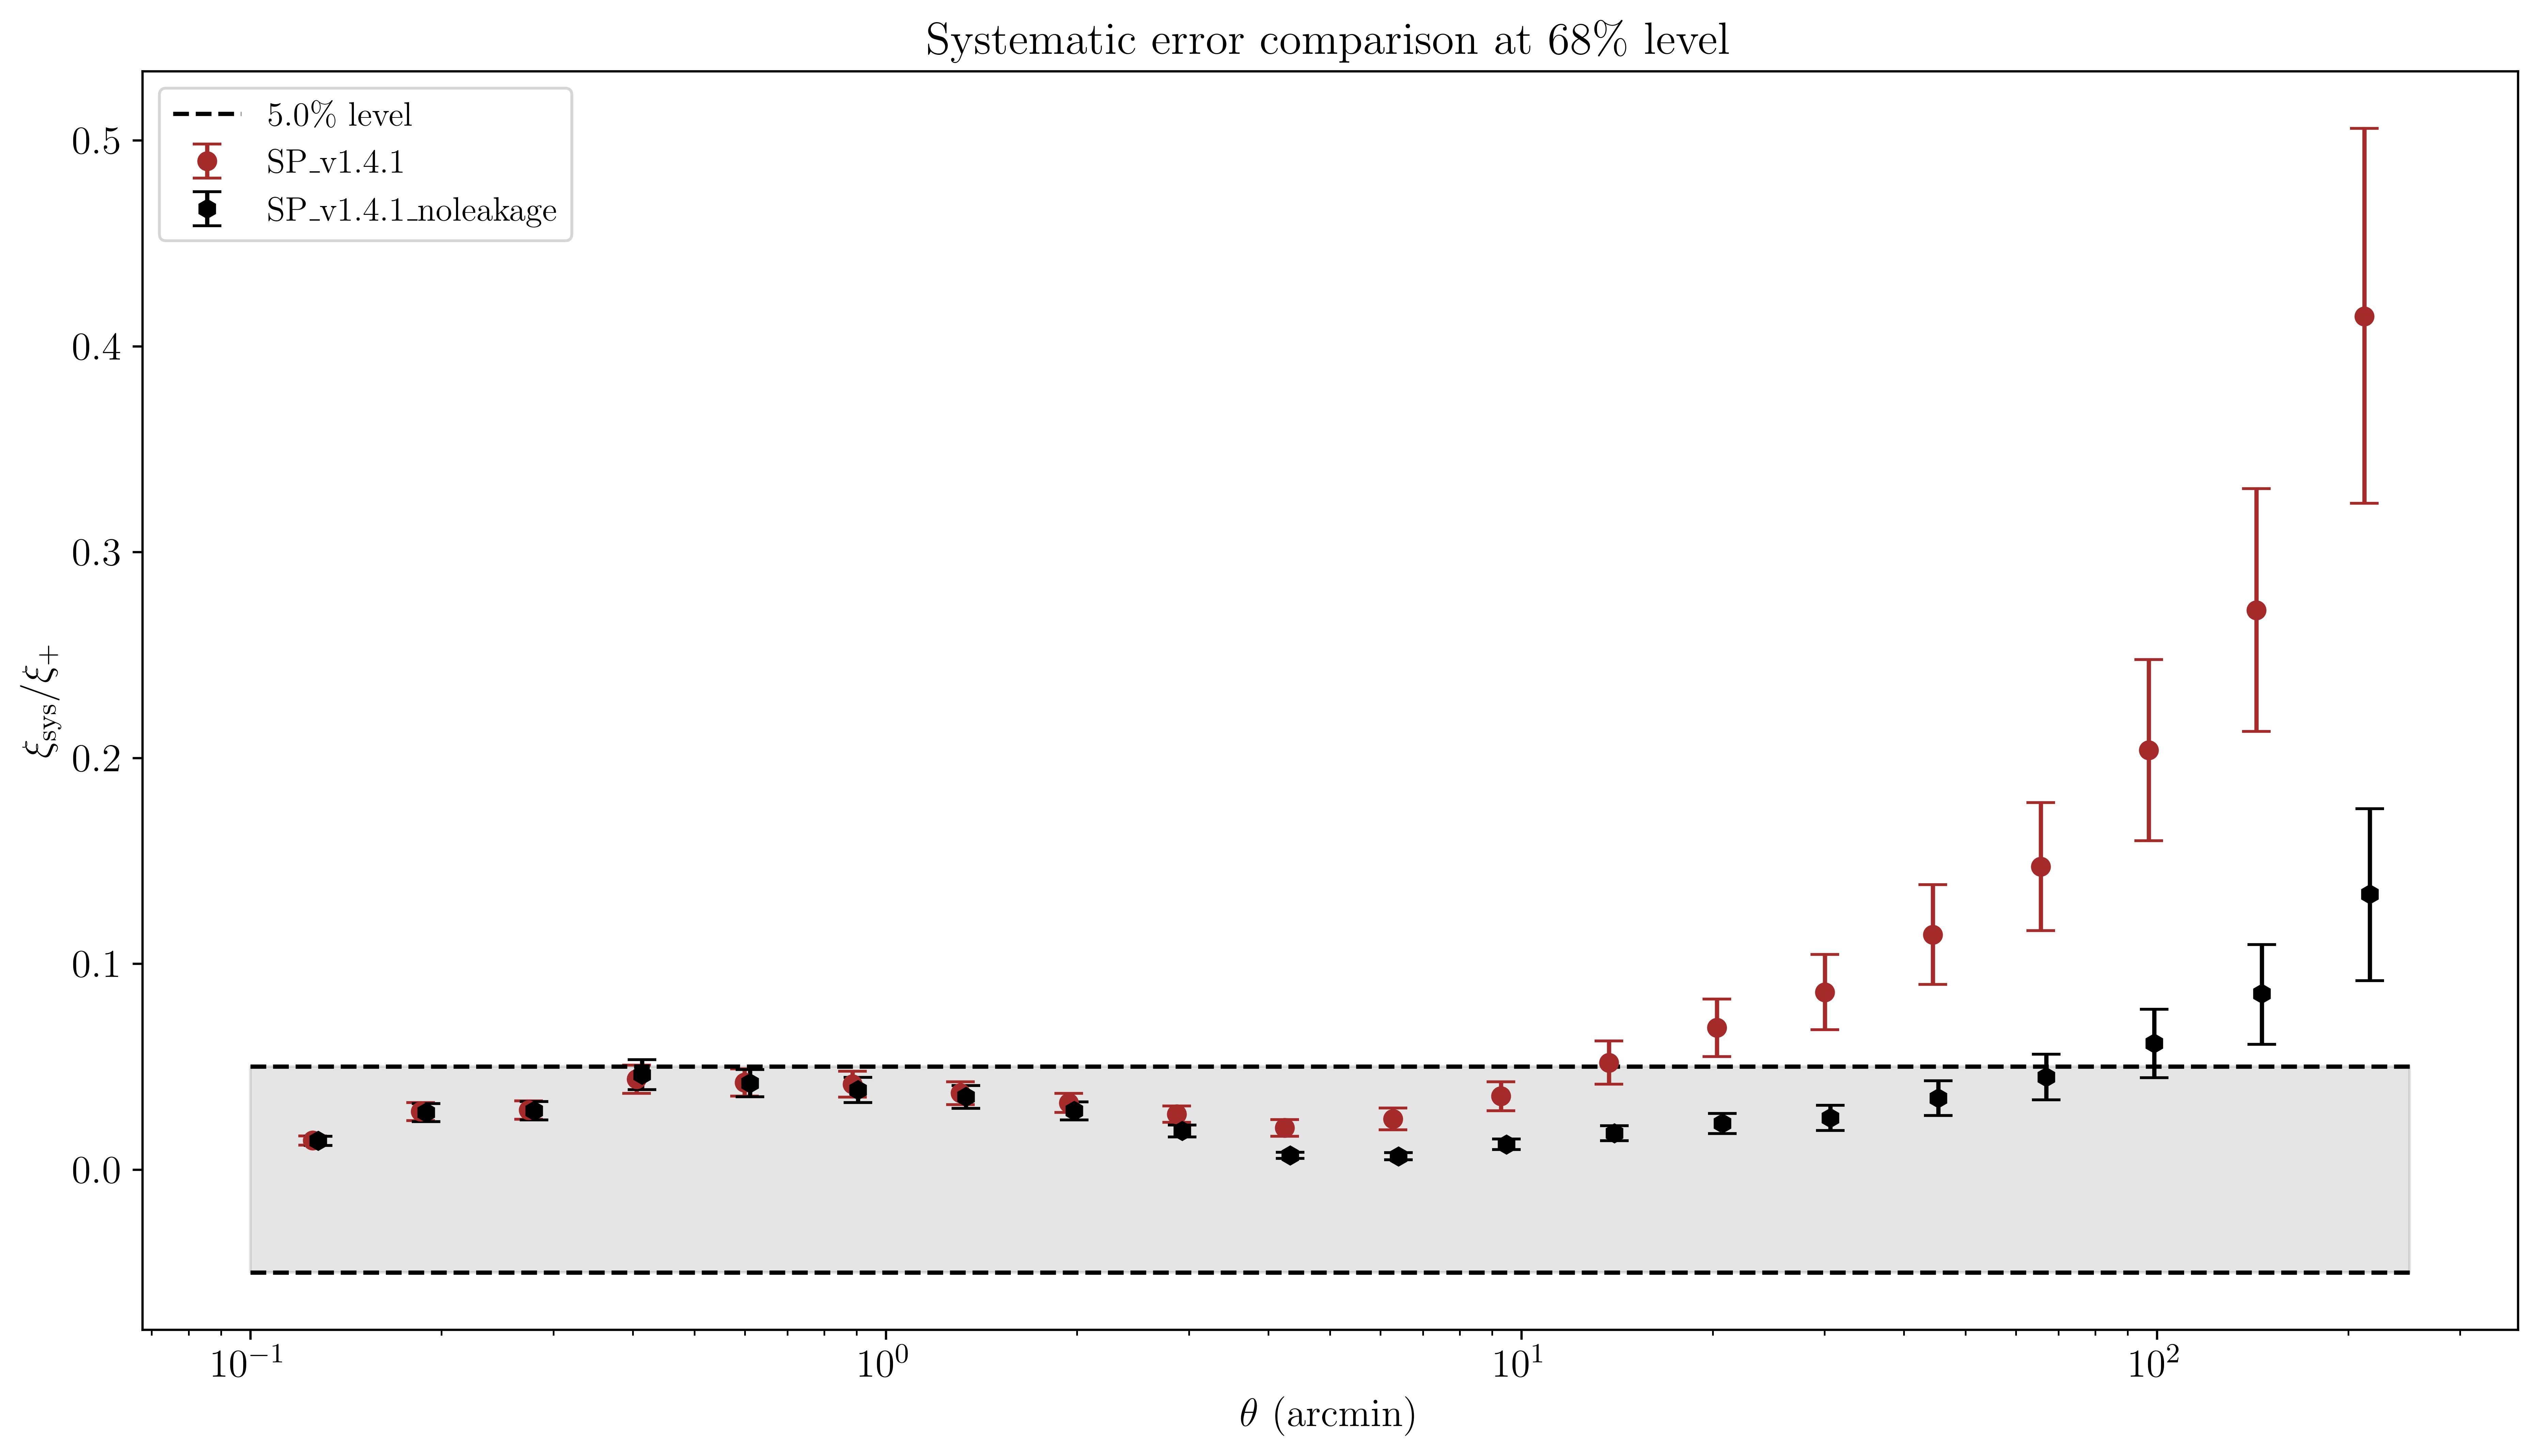

In [5]:
#versions = ['SP_v1.3_LFmask_8k', 'SP_v1.3_LFmask_8k_no_alpha', 'SP_v1.4-P1+3', 'SP_v1.4-P1+3_no_alpha', 'DES']
#colors = ['blue', 'blueviolet', 'brown', 'black', 'orange']
markers = ['o', 'h', 'd','x', '*']

#plot of the xi_sys
plt.figure()

offset = 0.02


for idx, (ver, color, marker) in enumerate(zip(versions, colors, markers)):
    print("Plotting version:", ver)
    sample = np.load(root_dir+'rho_tau_stats/samples_'+ver+'.npy')
    psf_fitter.load_rho_stat('rho_stats_'+ver+'.fits')
    quant = 0.84
    quantiles = [1-quant, quant]
    nbins = psf_fitter.rho_stat_handler._treecorr_config['nbins']
    xi_psf_sys_samples = np.array([]).reshape(0, nbins)
    for i in range(len(sample)):
        xi_psf_sys = psf_fitter.compute_xi_psf_sys(sample[i])
        xi_psf_sys_samples = np.vstack((xi_psf_sys_samples, xi_psf_sys))
    
    xi_psf_sys_mean = np.mean(xi_psf_sys_samples, axis=0)
    xi_psf_sys_quant = np.quantile(xi_psf_sys_samples, quantiles, axis=0)
    theta = psf_fitter.rho_stat_handler.rho_stats['theta']

    if os.path.exists(root_dir+'/xi_plus_'+ver+'.fits'):
        xi_plus = fits.getdata(root_dir+'/xi_plus_'+ver+'.fits')
        xip = xi_plus['VALUE']
    else:
        raise ValueError("File not found")

    ratio_mean = xi_psf_sys_mean/xip
    ratio_quant = xi_psf_sys_quant/xip

    jittered_theta = theta * (1+idx * offset)

    plt.errorbar(jittered_theta, ratio_mean, yerr=[ratio_mean-ratio_quant[0], ratio_quant[1]-ratio_mean], c=color, label=ver, fmt=marker, capsize=5)
    

threshold = 0.05
plt.fill_between([0.1, 250], [-threshold, -threshold], [threshold, threshold], color='black', alpha=0.1)
plt.plot([0.1, 250], [threshold, threshold], c='black', ls='--', label=str(threshold*100)+'\% level')
plt.plot([0.1, 250], [-threshold, -threshold], c='k', ls='--')
plt.xscale('log')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\rm sys}/\xi_{+}$')
plt.legend()
plt.title("Systematic error comparison at 68\% level")
plt.savefig('Plots/ratio_lq_comparison.png', dpi=600)
plt.show()

In [4]:
ratio_mean_des = ratio_mean

Plotting version: SP_v1.3_LFmask_8k


Plotting version: SP_v1.3_LFmask_8k_no_alpha
Plotting version: SP_v1.4.1
Plotting version: SP_v1.4.1_noleakage
Plotting version: DES


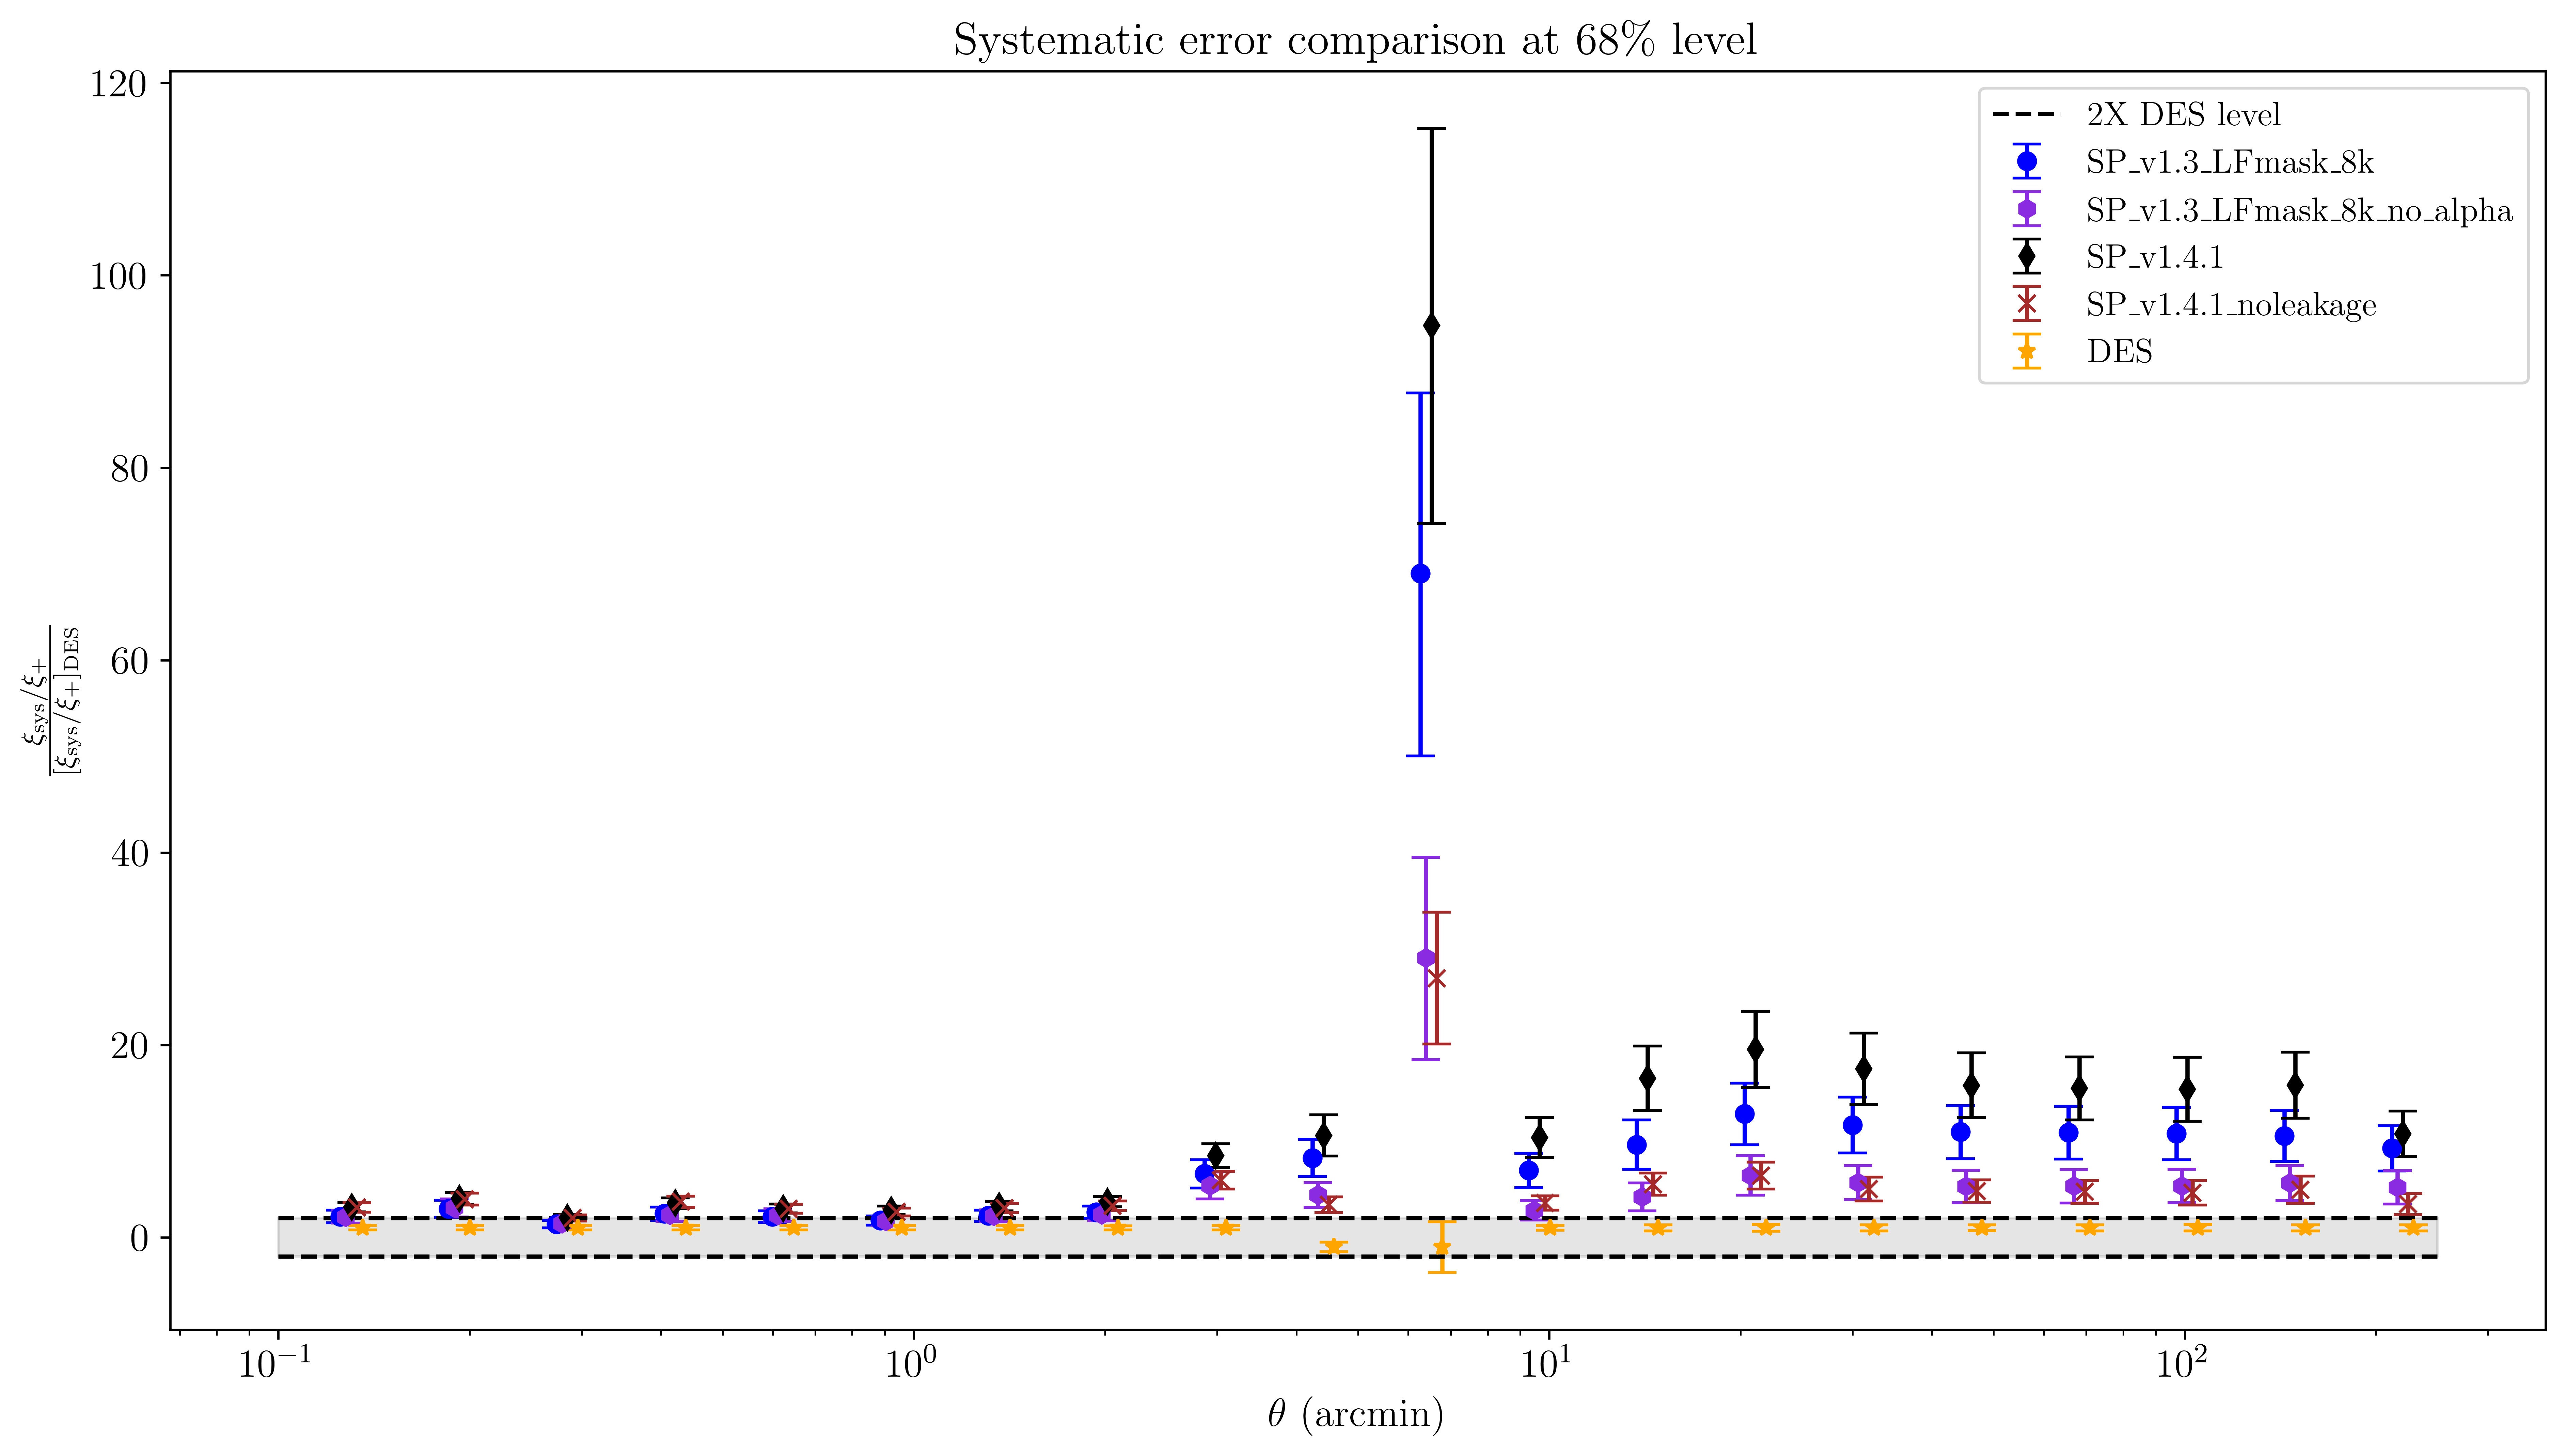

In [5]:
#versions = ['SP_v1.3_LFmask_8k', 'SP_v1.3_LFmask_8k_no_alpha', 'SP_v1.4-P1+3', 'SP_v1.4-P1+3_no_alpha']
#colors = ['blue', 'blueviolet', 'brown', 'black']
#markers = ['o', 'x', 'h', 'd']

#plot of the xi_sys
plt.figure()

for idx, (ver, color, marker) in enumerate(zip(versions, colors, markers)):
    print("Plotting version:", ver)
    sample = np.load(root_dir+'rho_tau_stats/samples_'+ver+'.npy')
    psf_fitter.load_rho_stat('rho_stats_'+ver+'.fits')
    quant = 0.84
    quantiles = [1-quant, quant]
    nbins = psf_fitter.rho_stat_handler._treecorr_config['nbins']
    xi_psf_sys_samples = np.array([]).reshape(0, nbins)
    for i in range(len(sample)):
        xi_psf_sys = psf_fitter.compute_xi_psf_sys(sample[i])
        xi_psf_sys_samples = np.vstack((xi_psf_sys_samples, xi_psf_sys))
    
    xi_psf_sys_mean = np.mean(xi_psf_sys_samples, axis=0)
    xi_psf_sys_quant = np.quantile(xi_psf_sys_samples, quantiles, axis=0)
    theta = psf_fitter.rho_stat_handler.rho_stats['theta']

    if os.path.exists(root_dir+'/xi_plus_'+ver+'.fits'):
        xi_plus = fits.getdata(root_dir+'/xi_plus_'+ver+'.fits')
        xip = xi_plus['VALUE']
    else:
        raise ValueError("File not found")

    ratio_mean = (xi_psf_sys_mean/xip)/np.abs(ratio_mean_des)
    ratio_quant = (xi_psf_sys_quant/xip)/np.abs(ratio_mean_des)

    jittered_theta = theta * (1+idx * offset)

    plt.errorbar(jittered_theta, ratio_mean, yerr=[ratio_mean-ratio_quant[0], ratio_quant[1]-ratio_mean], c=color, label=ver, fmt=marker, capsize=5)

threshold = 2
plt.fill_between([0.1, 250], [-threshold, -threshold], [threshold, threshold], color='black', alpha=0.1)
plt.plot([0.1, 250], [threshold, threshold], c='black', ls='--', label=str(threshold)+'X DES level')
plt.plot([0.1, 250], [-threshold, -threshold], c='k', ls='--')
plt.xscale('log')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\frac{\xi_{\rm sys}/\xi_{+}}{[\xi_{\rm sys}/\xi_{+}]_{\rm DES}}$')
plt.legend()
plt.title("Systematic error comparison at 68\% level")
plt.savefig('Plots/ratio_DES.png', dpi=600)
plt.show()

## Reproduce plot axel

### Compare rho-stats

In [6]:
base_dir = '/sps/euclid/Users/sguerrin/results/cov_mat/'

""" #versions = [
    'DES',
    'SP_v0.0',
    'SP_v1.3_LFmask_8k_SN7',
    'SP_v1.3_LFmask_8k_wcs',
    'SP_v1.4-P1+3'
]

#colors = [
    'orange',
    'cyan',
    'g',
    'blue',
    'brown'
] """

filenames_rho = [
    base_dir+'/'+version+'/rho_stats_'+version+'.fits' for version in versions
]

filenames_tau = [
    base_dir+'/'+version+'/tau_stats_'+version+'.fits' for version in versions
]

Plotting version: SP_v1.4.1
Plotting version: SP_v1.4.1_noleakage


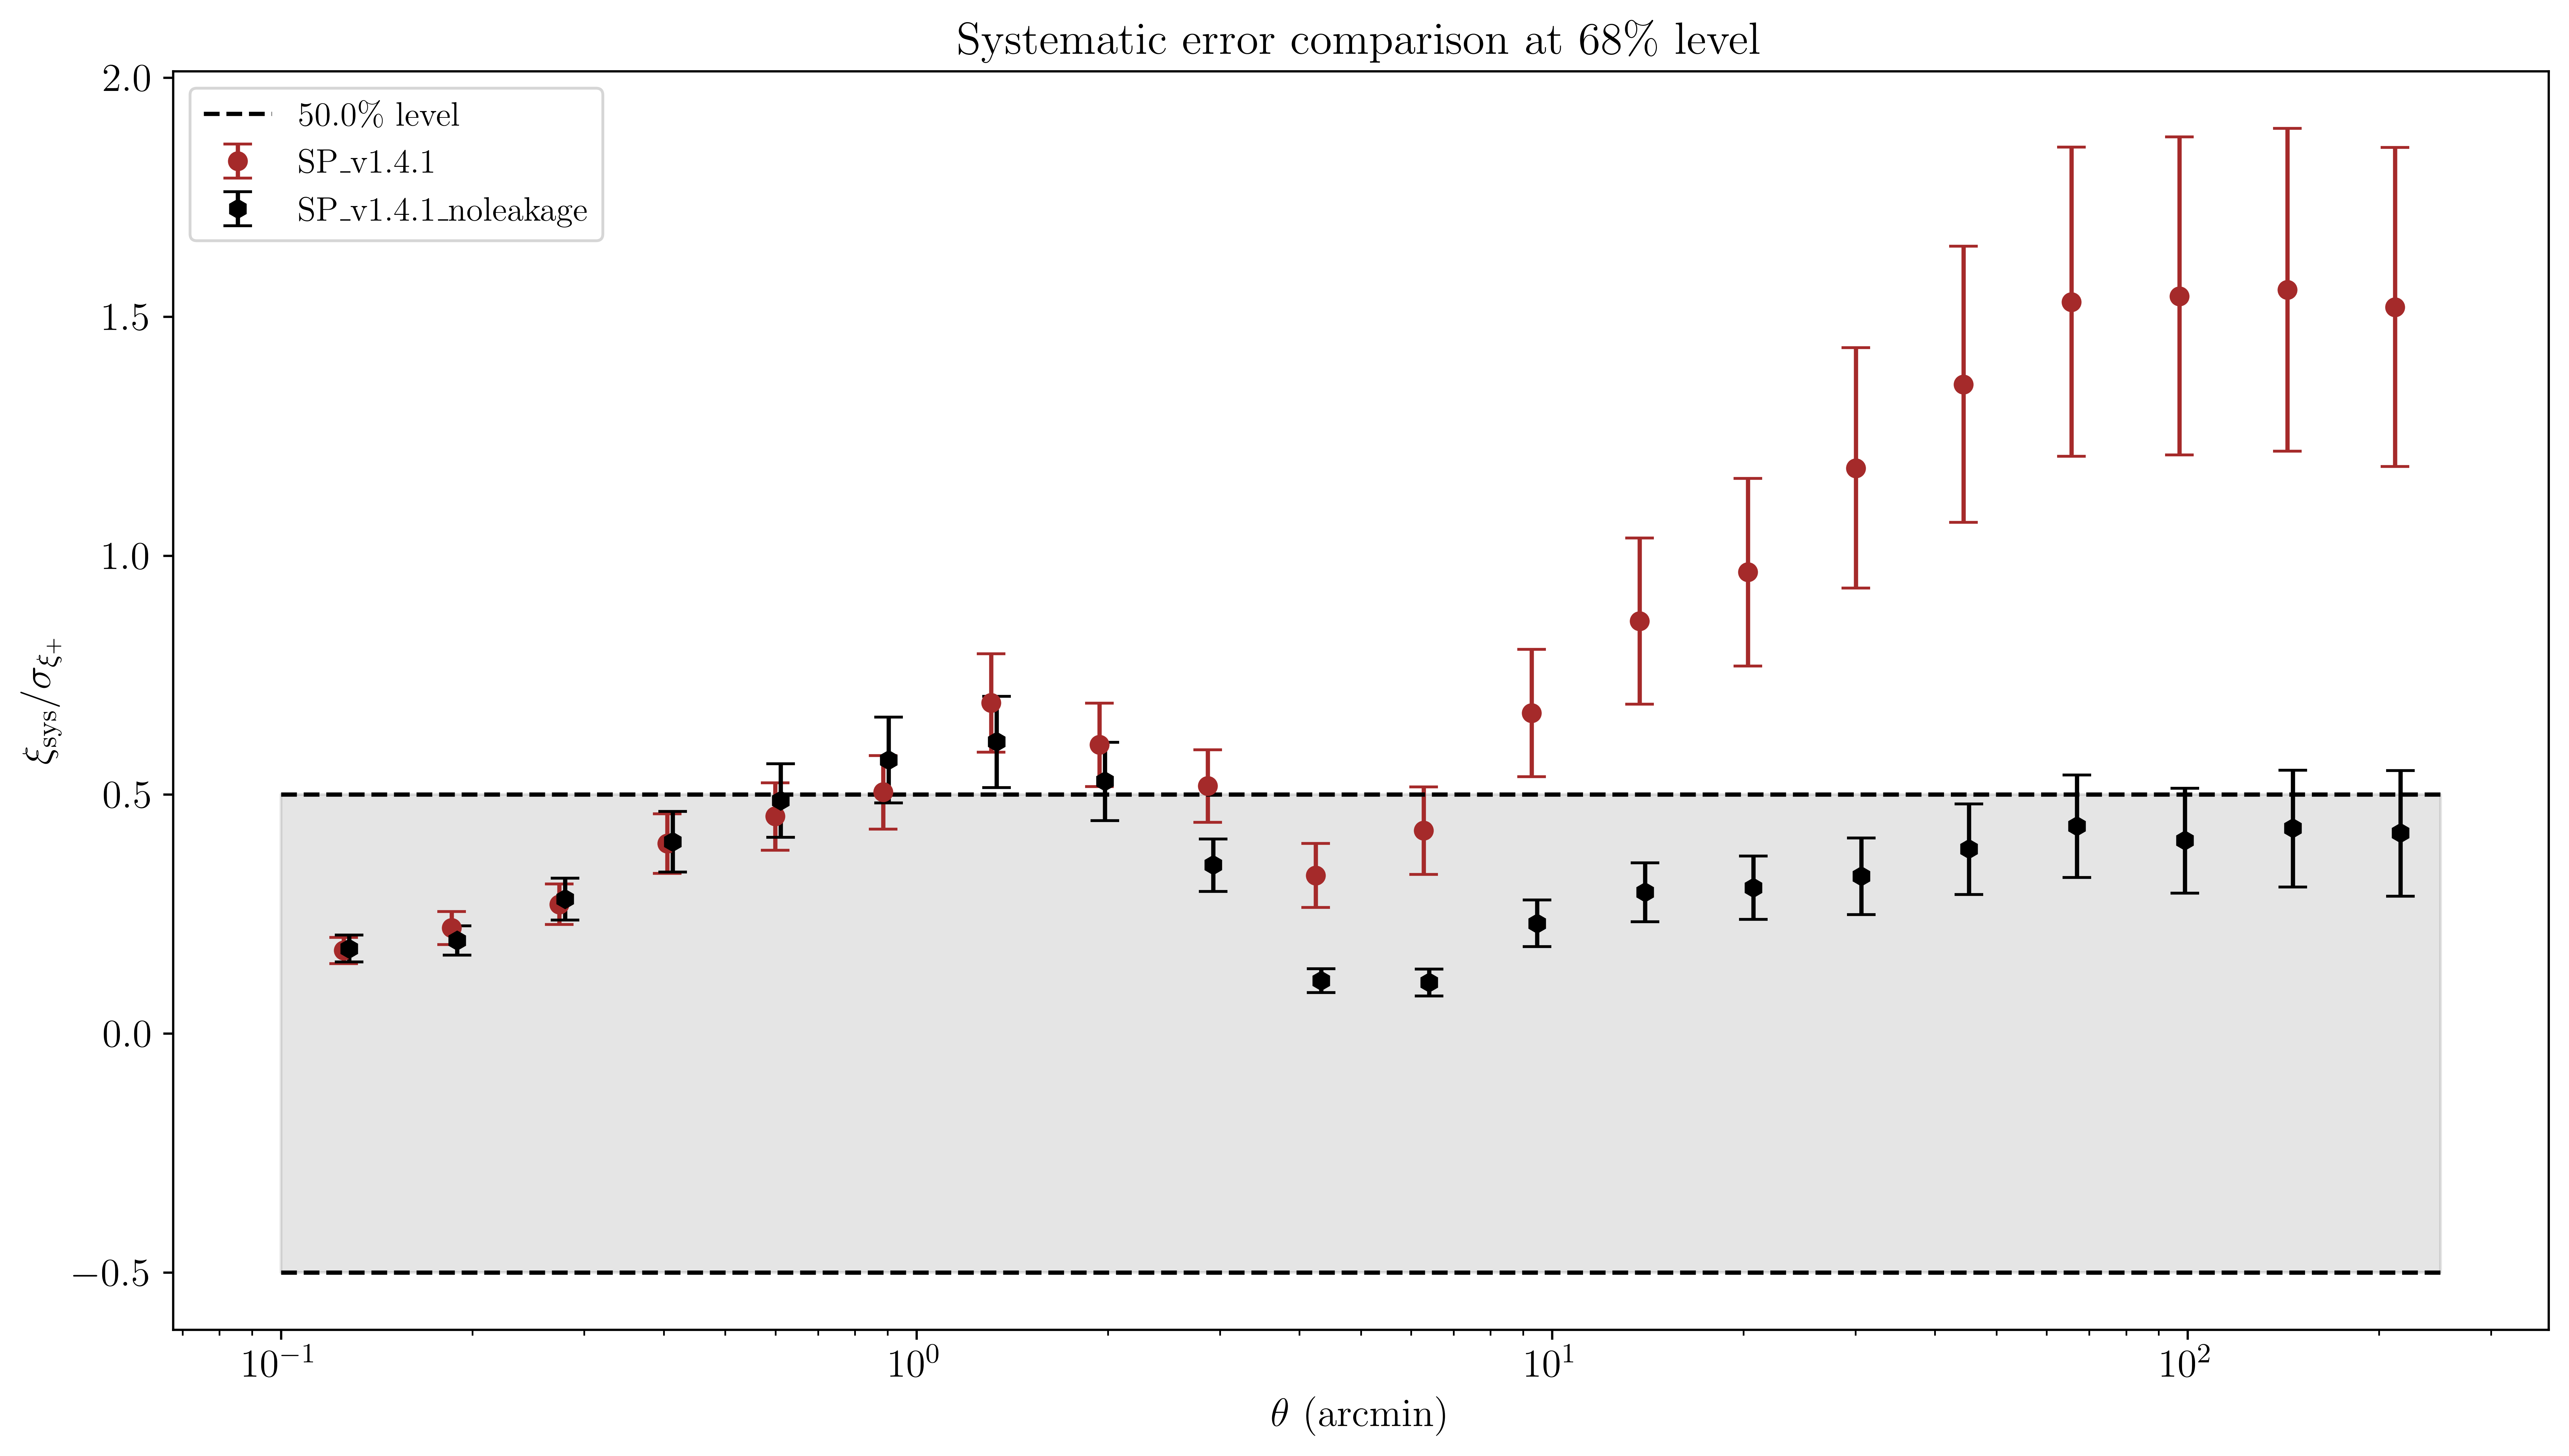

In [7]:
#versions = ['SP_v1.3_LFmask_8k', 'SP_v1.3_LFmask_8k_no_alpha', 'SP_v1.4-P1+3', 'SP_v1.4-P1+3_no_alpha', 'DES']
#colors = ['blue', 'blueviolet', 'brown', 'black', 'orange']
#markers = ['o', 'x', 'h', 'd', '*']

#plot of the xi_sys
plt.figure()

for idx, (ver, color, marker) in enumerate(zip(versions, colors, markers)):
    print("Plotting version:", ver)
    sample = np.load(root_dir+'rho_tau_stats/samples_'+ver+'.npy')
    psf_fitter.load_rho_stat('rho_stats_'+ver+'.fits')
    quant = 0.84
    quantiles = [1-quant, quant]
    nbins = psf_fitter.rho_stat_handler._treecorr_config['nbins']
    xi_psf_sys_samples = np.array([]).reshape(0, nbins)
    for i in range(len(sample)):
        xi_psf_sys = psf_fitter.compute_xi_psf_sys(sample[i])
        xi_psf_sys_samples = np.vstack((xi_psf_sys_samples, xi_psf_sys))
    
    xi_psf_sys_mean = np.mean(xi_psf_sys_samples, axis=0)
    xi_psf_sys_quant = np.quantile(xi_psf_sys_samples, quantiles, axis=0)
    theta = psf_fitter.rho_stat_handler.rho_stats['theta']

    if os.path.exists(root_dir+'/xi_pm_'+ver+'.txt'):
        xi_plus = fits.getdata(root_dir+'/xi_plus_'+ver+'.fits')
        xip = xi_plus['VALUE']
        gg = treecorr.GGCorrelation(TreeCorrConfig_xi)
        gg.read(root_dir+'/xi_pm_'+ver+'.txt')
        varxip = gg.varxip

    ratio_mean = xi_psf_sys_mean/np.sqrt(varxip)
    ratio_quant = xi_psf_sys_quant/np.sqrt(varxip)
    jittered_theta = theta * (1+idx * offset)

    plt.errorbar(jittered_theta, ratio_mean, yerr=[ratio_mean-ratio_quant[0], ratio_quant[1]-ratio_mean], c=color, label=ver, fmt=marker, capsize=5)

threshold = 0.50
plt.fill_between([0.1, 250], [-threshold, -threshold], [threshold, threshold], color='black', alpha=0.1)
plt.plot([0.1, 250], [threshold, threshold], c='black', ls='--', label=str(threshold*100)+'\% level')
plt.plot([0.1, 250], [-threshold, -threshold], c='k', ls='--')
plt.xscale('log')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_{\rm sys}/\sigma_{\xi_+}$')
plt.legend()
plt.title("Systematic error comparison at 68\% level")
plt.savefig('Plots/ratio_varxip_lq_comparison.png', dpi=600)
plt.show()

### Plot sigma_xi_+

In [8]:
plt.figure(figsize=(15, 15))

for ver, color in zip(versions, colors):
    gg = treecorr.GGCorrelation(TreeCorrConfig_xi)
    gg.read(root_dir+'/xi_pm_'+ver+'.txt')
    plt.plot(gg.meanr, np.sqrt(gg.varxip), label=ver, color=color)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\sigma_{\xi_+}$')
plt.legend()
plt.savefig('Plots/sigma_xip_comparison.png', dpi=600)
plt.show()

### Plot xi_+

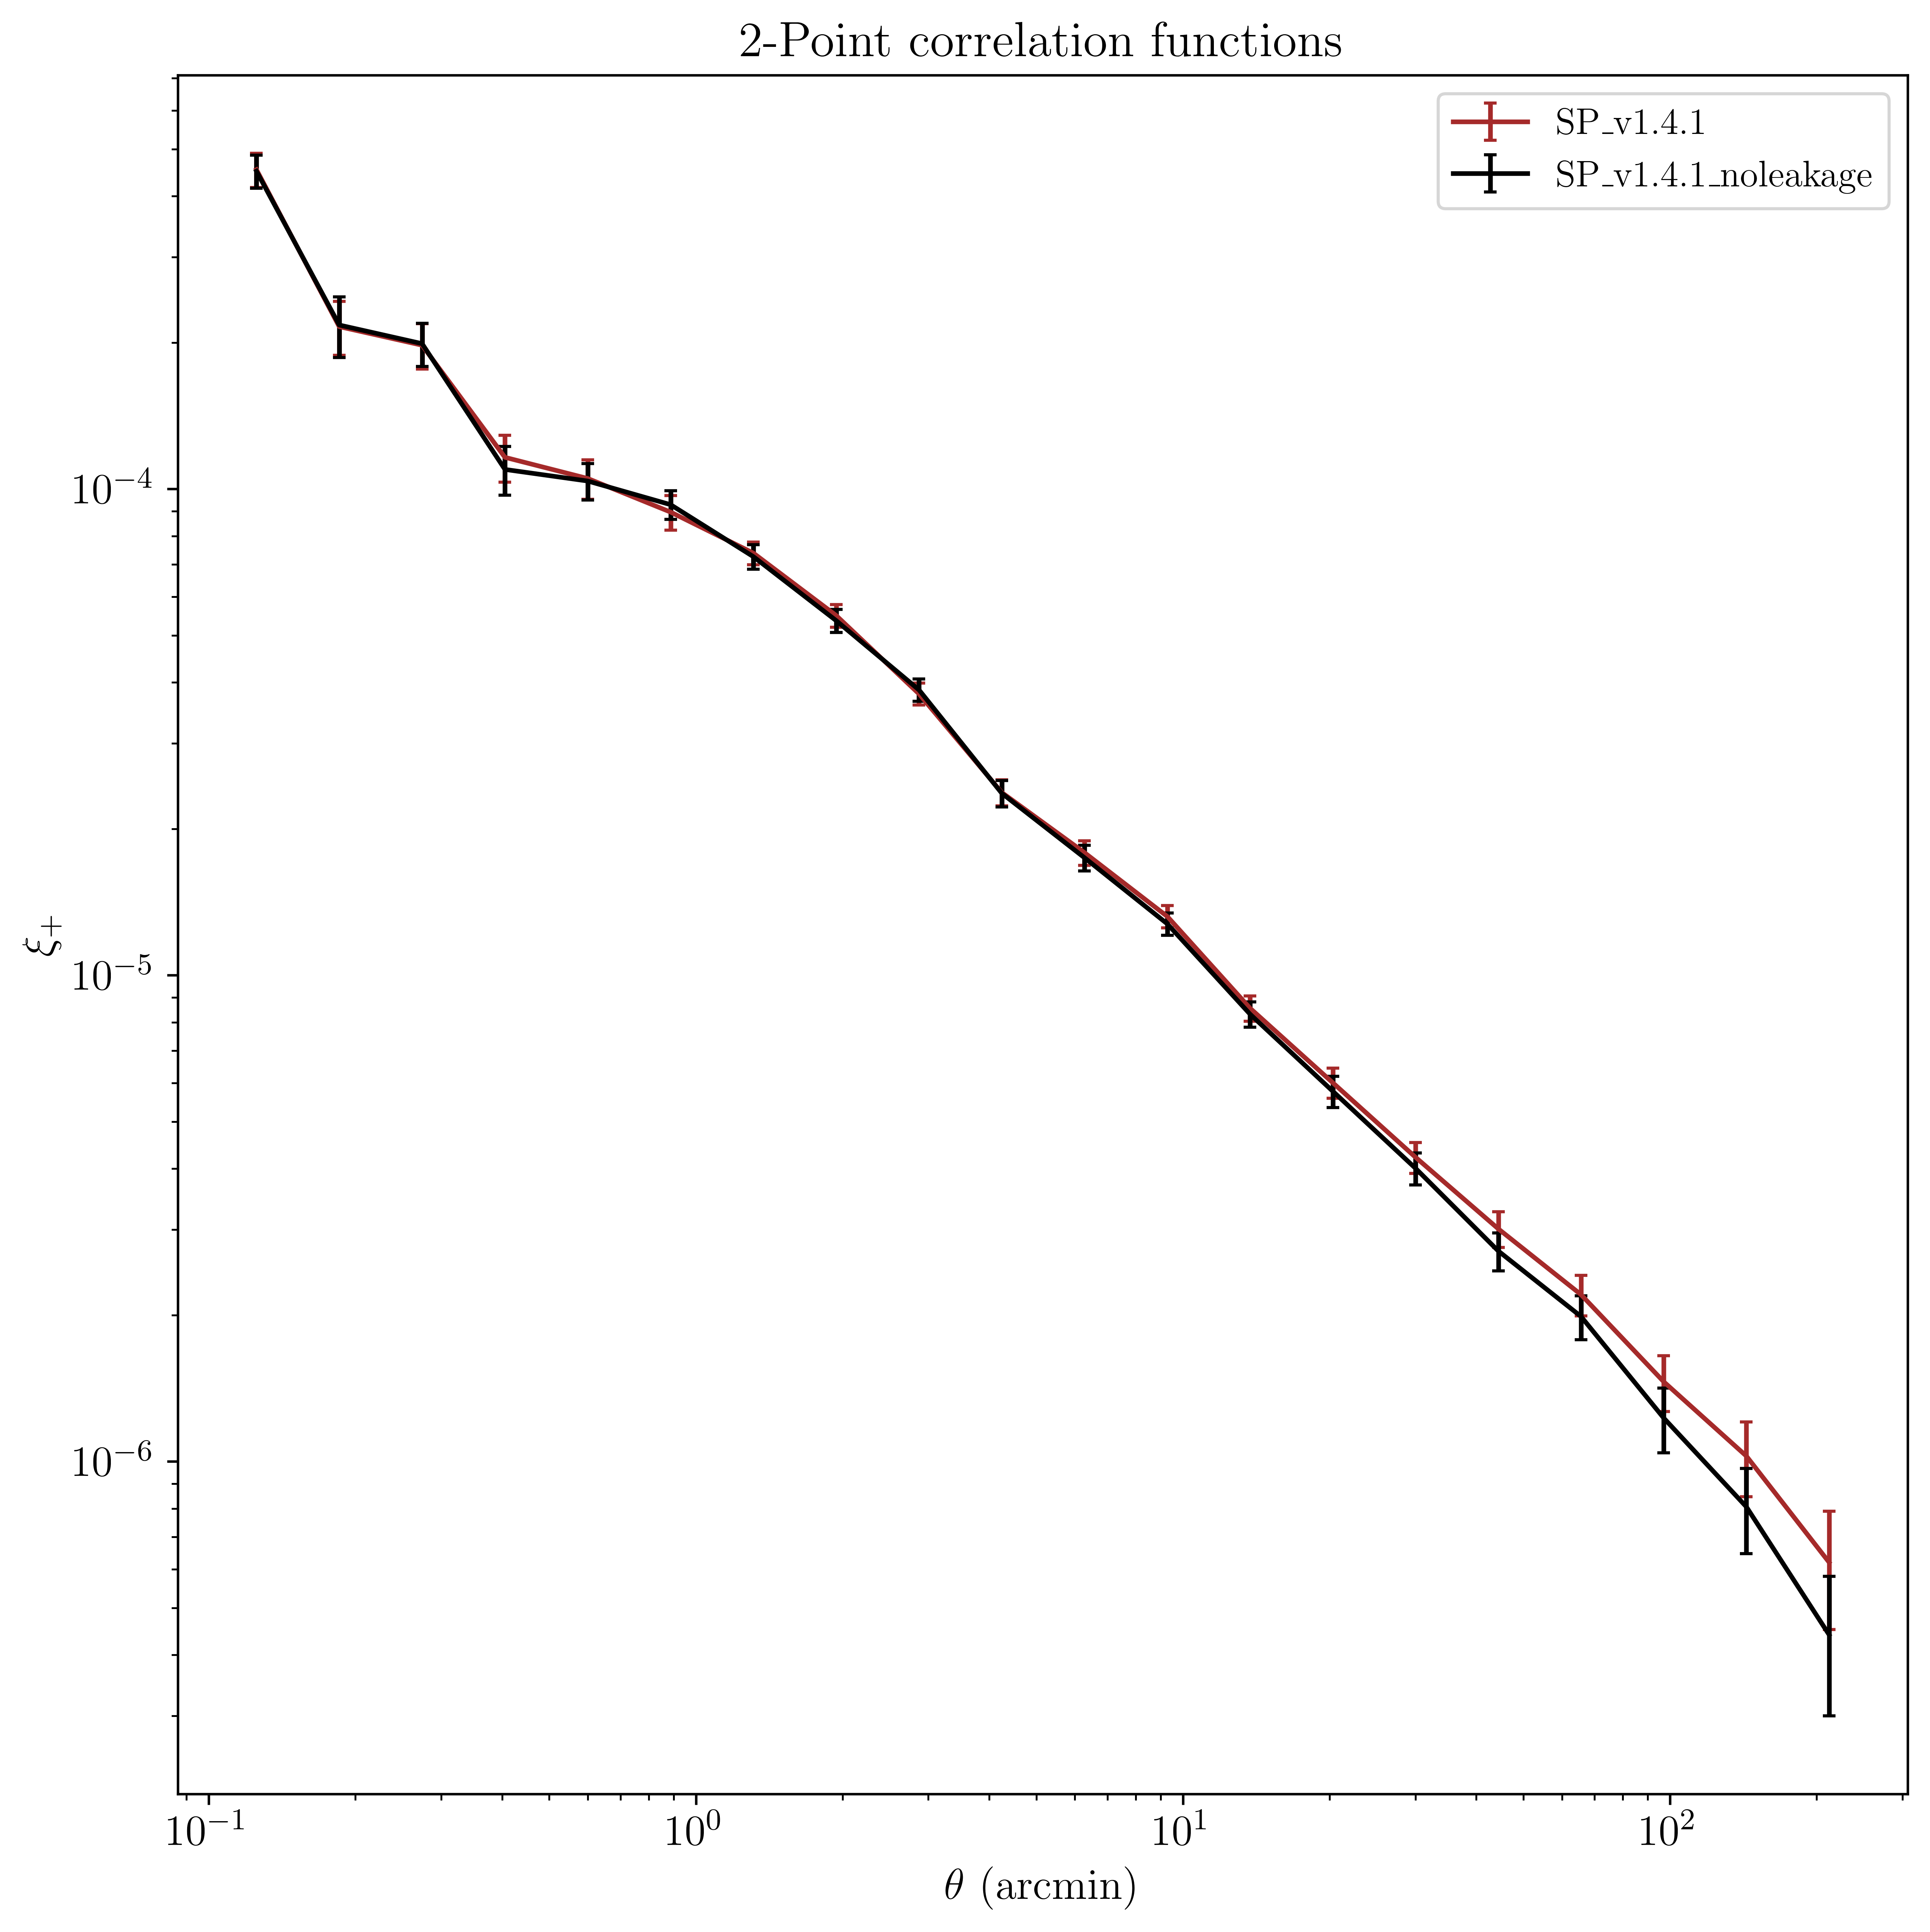

In [9]:
plt.figure(figsize=(10, 10))

for ver, color in zip(versions, colors):
    gg = treecorr.GGCorrelation(TreeCorrConfig_xi)
    gg.read(root_dir+'/xi_pm_'+ver+'.txt')
    plt.errorbar(gg.meanr, gg.xip, yerr=np.sqrt(gg.varxip), label=ver, color=color, capsize=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\xi_+$')
plt.title("2-Point correlation functions")
plt.legend()
plt.savefig('./Plots/xi_p.png', dpi=600)
plt.show()

In [11]:
theta_min = 0.3
theta_max = 200
nbins = 500
npatch = 25

TreeCorrConfig_map = {
        'ra_units': coord_units,
        'dec_units': coord_units,
        'max_sep': str(theta_max),
        'min_sep': str(theta_min),
        'sep_units': sep_units,
        'nbins': nbins,
        'var_method':'jackknife',
}

n_bins_map = 15
theta_map = np.geomspace(theta_min * 5, theta_max / 2, n_bins_map)

Plotting version: SP_v1.4.1
Plotting version: SP_v1.4.1_noleakage


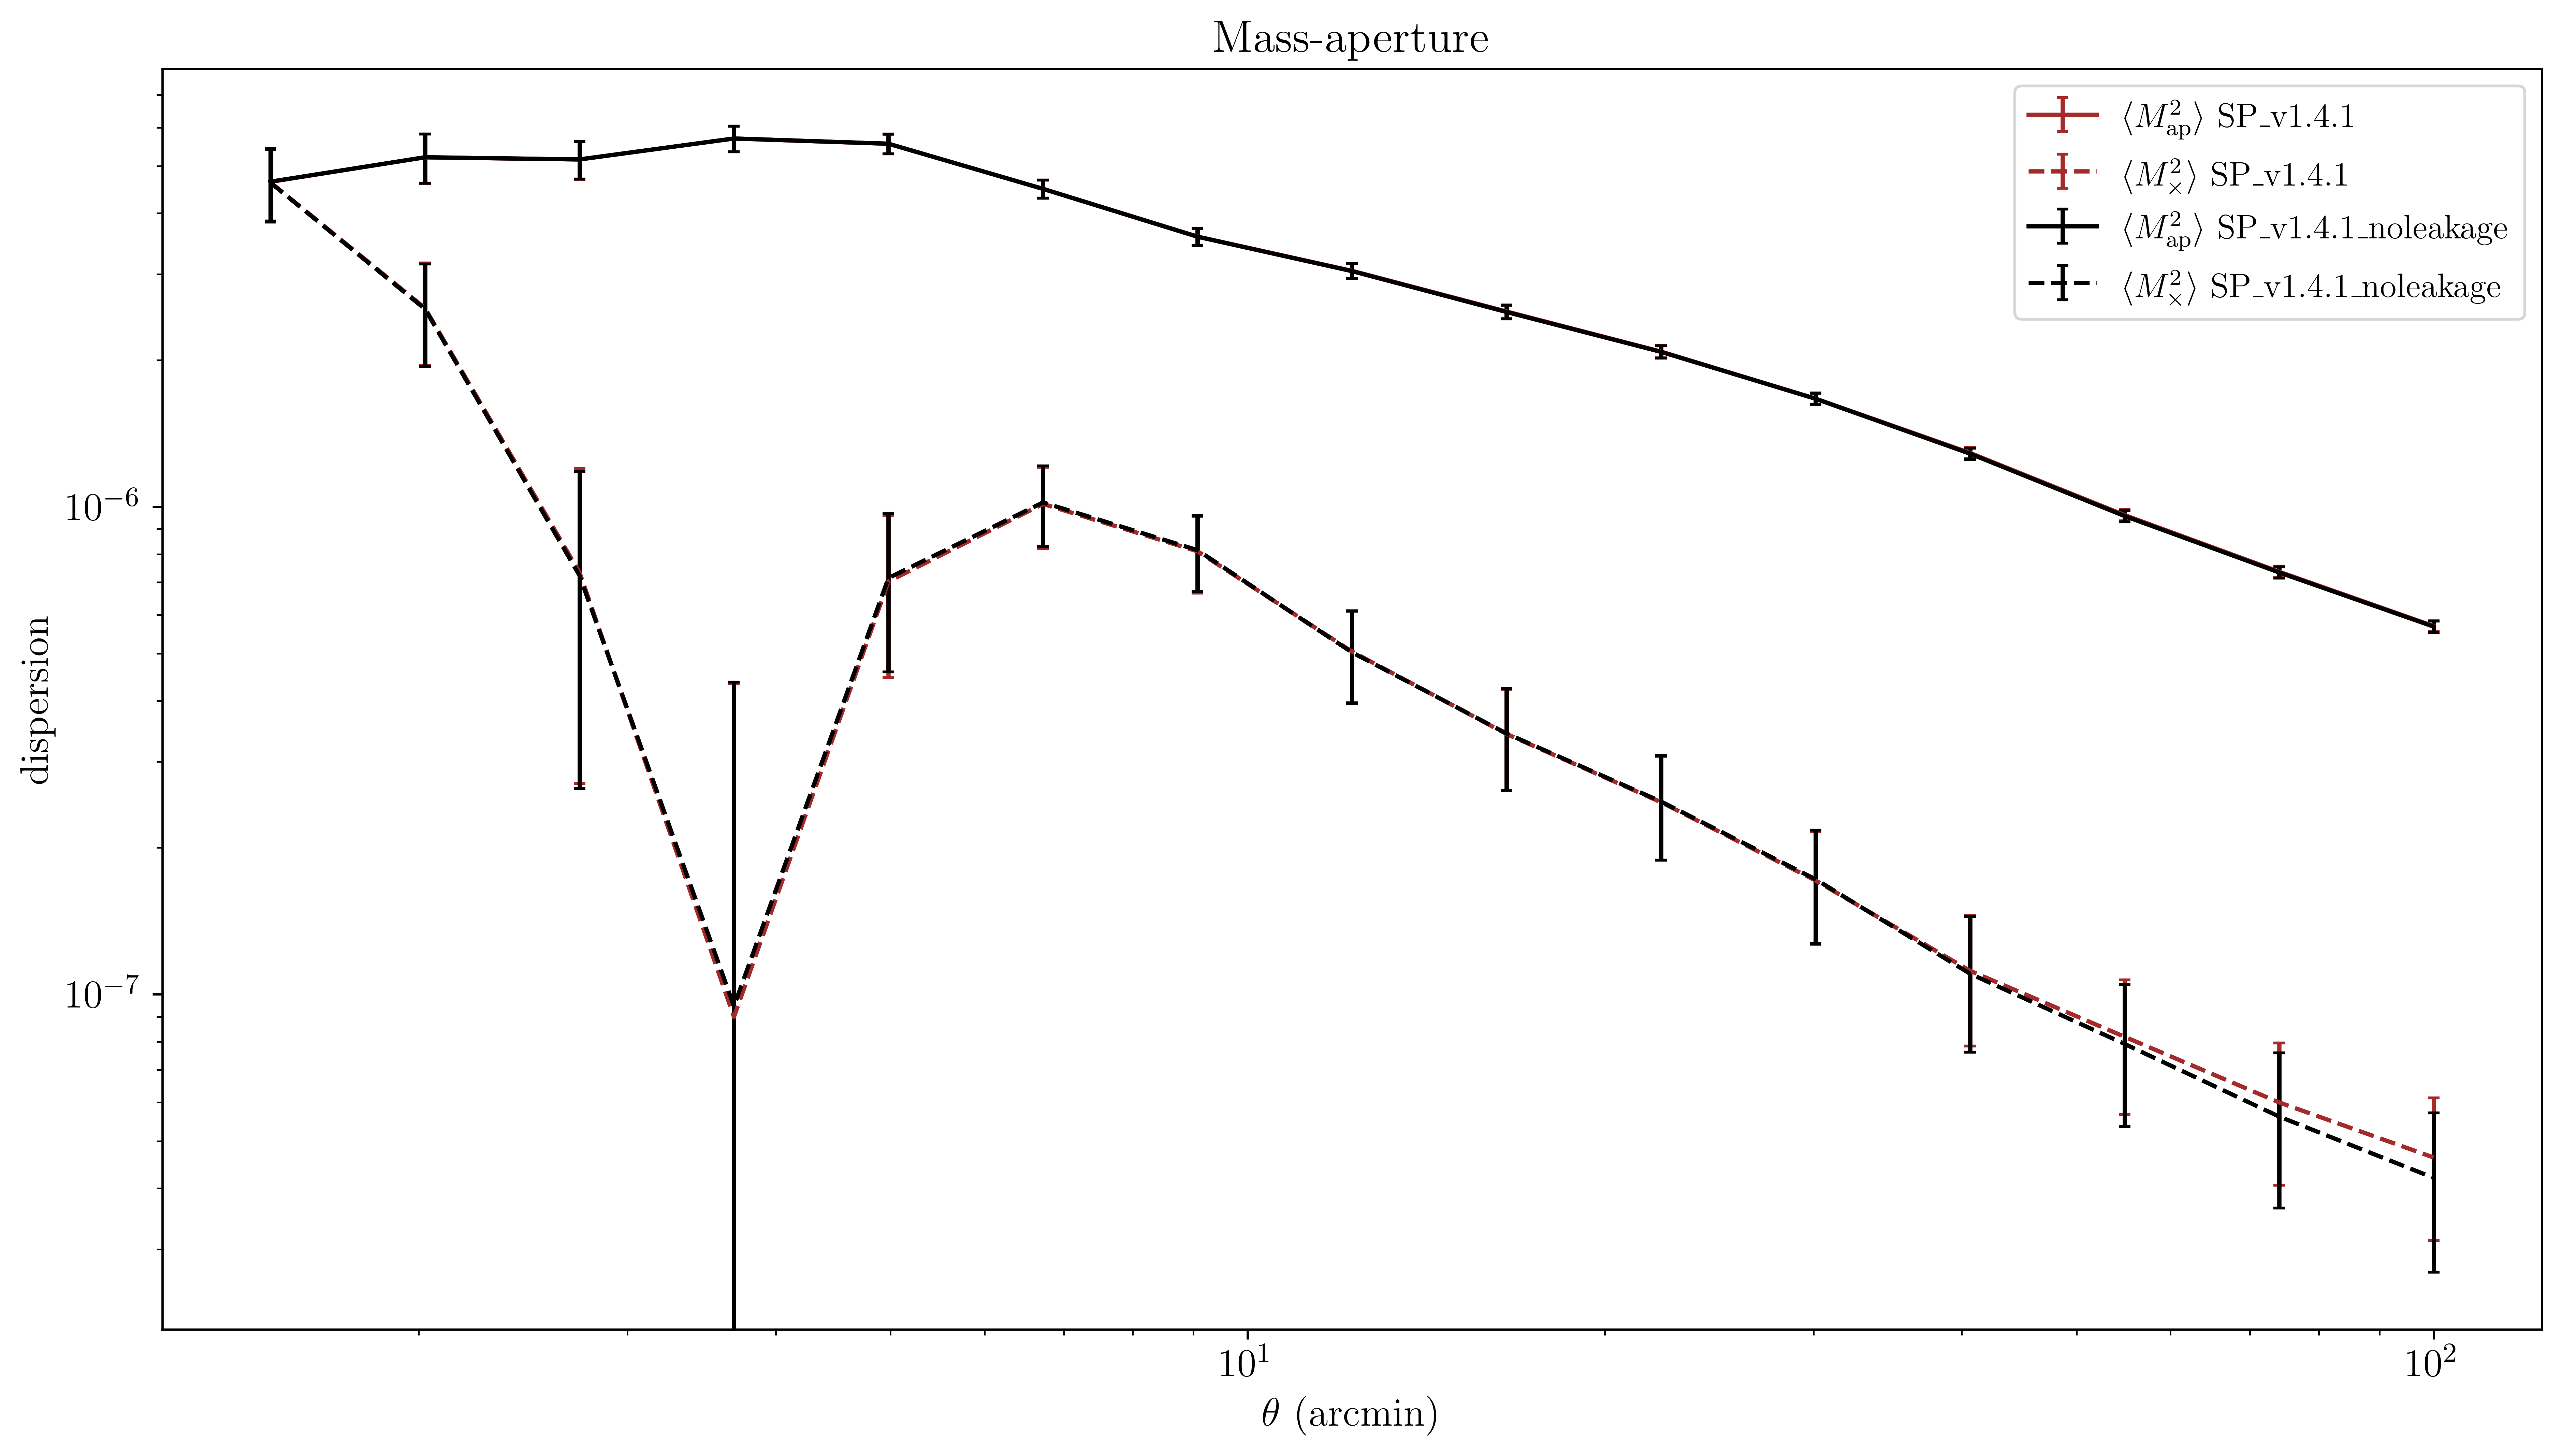

In [22]:
gg = treecorr.GGCorrelation(TreeCorrConfig_map)

#plot of the xi_sys
plt.figure()

for ver, color in zip(versions, colors):
    print("Plotting version:", ver)
    gg.read(root_dir+f'xi_for_map2_{ver}.txt')

    mapsq, mapsq_im, mxsq, mxsq_im, varmapsq = gg.calculateMapSq(
        R=theta_map,
        m2_uform='Schneider',
    )
    plt.errorbar(theta_map, mapsq, yerr=np.sqrt(varmapsq), c=color, label=r'$\langle M^2_{\rm ap} \rangle$ '+ver, capsize=2)
    plt.errorbar(theta_map, np.abs(mxsq), yerr=np.sqrt(varmapsq), c=color, ls='--', label=r'$\langle M^2_\times \rangle$ '+ver, capsize=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'dispersion')
plt.title('Mass-aperture')
plt.legend()
plt.savefig('Plots/map_sq_comparison.png', dpi=600)
plt.show()